<a href="https://www.kaggle.com/code/oladayofolasire/chi-square-test-of-independent-mental-health?scriptVersionId=309103383" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# Import packages for data manipulation
# Import relevant libraries and modules.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This displays all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

# This module lets us save our models once we fit them.
import pickle

# This lets us see all of the columns, preventing Juptyer from redacting them.
pd.set_option('display.max_columns', None)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/oladayofolasire/mental-health-in-tech/survey.csv


In [2]:
# Read in data
file = '/kaggle/input/datasets/oladayofolasire/mental-health-in-tech/survey.csv'
df1 = pd.read_csv(file)
df1.head(10)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Sometimes,6-25,No,Yes,Yes,Not sure,No,Don't know,Don't know,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Sometimes,1-5,Yes,Yes,No,No,No,No,No,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Never,1-5,Yes,Yes,No,Yes,No,No,Yes,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Sometimes,100-500,No,Yes,Yes,Yes,No,No,No,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Never,26-100,No,Yes,Don't know,No,Don't know,Don't know,Don't know,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN


In [3]:
df1.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments'],
      dtype='object')

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [5]:
df1.dtypes

Timestamp                    object
Age                           int64
Gender                       object
Country                      object
state                        object
self_employed                object
family_history               object
treatment                    object
work_interfere               object
no_employees                 object
remote_work                  object
tech_company                 object
benefits                     object
care_options                 object
wellness_program             object
seek_help                    object
anonymity                    object
leave                        object
mental_health_consequence    object
phys_health_consequence      object
coworkers                    object
supervisor                   object
mental_health_interview      object
phys_health_interview        object
mental_vs_physical           object
obs_consequence              object
comments                     object
dtype: object

In [6]:
df1.shape

(1259, 27)

In [7]:
df1.size

33993

In [8]:
df1.isna().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [9]:
df_clean = df1[['Age', 'treatment']].copy()

In [10]:
df_clean.head(10)

,Age,treatment
0,37,Yes
1,44,No
2,32,No
3,31,Yes
4,31,No
5,33,No
6,35,Yes
7,39,No
8,42,Yes
9,23,No


In [11]:
df_clean.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [12]:
df_clean.dtypes

Age           int64
treatment    object
dtype: object

In [13]:
df_clean.isna().sum()

Age          0
treatment    0
dtype: int64

In [14]:
df_clean['treatment'].value_counts(dropna=False)

treatment
Yes    637
No     622
Name: count, dtype: int64

In [15]:
df_clean['treatment'] = df_clean['treatment'].map({'Yes': 1, 'No': 0})

In [16]:
df_clean.head()

,Age,treatment
0,37,1
1,44,0
2,32,0
3,31,1
4,31,0


In [17]:
df_clean['treatment'].value_counts()

treatment
1    637
0    622
Name: count, dtype: int64

In [18]:
## df_clean['Age'] > 15. That means any age strictly greater than 15 is kept, so the smallest age that remains is 16. It’s just a way to remove any ages 15 or below, which are likely invalid for your dataset context (e.g., working-age adults).##
                                                                        


In [19]:
 df_clean = df_clean[(df_clean['Age'] > 15) & (df_clean['Age'] < 100)]

In [20]:
df_clean['Age'].describe()

count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64

In [21]:
df_clean['age_group'] = pd.cut(
    df_clean['Age'],
    bins=[18, 25, 35, 45, 55, 100],
    labels=['18-24', '25-34', '35-44', '45-54', '55+'],
    right=False
)

In [22]:
df_clean['age_group'].value_counts().sort_index()

age_group
18-24    156
25-34    707
35-44    320
45-54     51
55+       17
Name: count, dtype: int64

In [23]:
# One-hot encode age_group
age_dummies = pd.get_dummies(df_clean['age_group'], prefix='age')

# Add the new columns to df_clean
df_clean = pd.concat([df_clean, age_dummies], axis=1)

# Optionally, drop the original age_group column
df_clean = df_clean.drop(columns=['age_group'])

# Check result
df_clean.head()

,Age,treatment,age_18-24,age_25-34,age_35-44,age_45-54,age_55+
0,37,1,False,False,True,False,False
1,44,0,False,False,True,False,False
2,32,0,False,True,False,False,False
3,31,1,False,True,False,False,False
4,31,0,False,True,False,False,False


In [24]:
# Convert all columns starting with 'age_' to int
age_cols = [col for col in df_clean.columns if col.startswith('age_')]
df_clean[age_cols] = df_clean[age_cols].astype(int)

# Check
df_clean[age_cols].head()

,age_18-24,age_25-34,age_35-44,age_45-54,age_55+
0,0,0,1,0,0
1,0,0,1,0,0
2,0,1,0,0,0
3,0,1,0,0,0
4,0,1,0,0,0


In [25]:
df_clean.head()

,Age,treatment,age_18-24,age_25-34,age_35-44,age_45-54,age_55+
0,37,1,0,0,1,0,0
1,44,0,0,0,1,0,0
2,32,0,0,1,0,0,0
3,31,1,0,1,0,0,0
4,31,0,0,1,0,0,0


In [26]:
df_clean.columns

Index(['Age', 'treatment', 'age_18-24', 'age_25-34', 'age_35-44', 'age_45-54',
       'age_55+'],
      dtype='object')

In [27]:
# List of age dummy columns
age_cols = ['age_18-24', 'age_25-34', 'age_35-44', 'age_45-54', 'age_55+']

# Create contingency table
contingency = pd.DataFrame({
    'Treated': df_clean[age_cols].T.dot(df_clean['treatment']),
    'Not_Treated': df_clean[age_cols].sum(axis=0) - df_clean[age_cols].T.dot(df_clean['treatment'])
})

print(contingency)

           Treated  Not_Treated
age_18-24       70           86
age_25-34      346          361
age_35-44      175          145
age_45-54       29           22
age_55+         12            5


In [28]:
##Use Chi-square test of independence. It checks if treatment distribution differs by age group.##

In [29]:
from scipy.stats import chi2_contingency

# Convert contingency table to array for the test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi2 Statistic:", chi2)
print("p-value:", p)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)

Chi2 Statistic: 8.480732889981047
p-value: 0.07547339893083327
Degrees of Freedom: 4
Expected Frequencies:
 [[ 78.81055156  77.18944844]
 [357.17346123 349.82653877]
 [161.66266986 158.33733014]
 [ 25.76498801  25.23501199]
 [  8.58832934   8.41167066]]


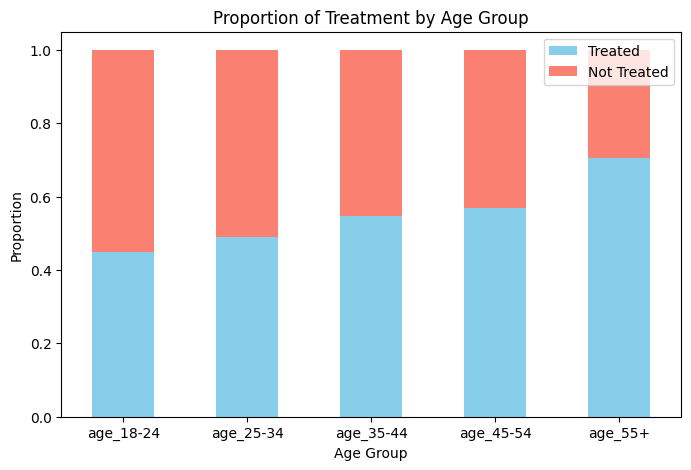

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate percentages for visualization
contingency_pct = contingency.div(contingency.sum(axis=1), axis=0)

# Stacked bar plot
contingency_pct.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'], figsize=(8,5))

plt.title('Proportion of Treatment by Age Group')
plt.ylabel('Proportion')
plt.xlabel('Age Group')
plt.legend(['Treated', 'Not Treated'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

In [31]:
##Interpretation: There isn’t enough evidence to reject the null hypothesis at the 5% significance level. This means age does not have a statistically significant effect on whether someone seeks treatment##

In [32]:
# Dataset Note: This dataset is from a 2014 survey that measures attitudes towards mental health
# and frequency of mental health disorders in the tech workplace. Source: Kaggle.